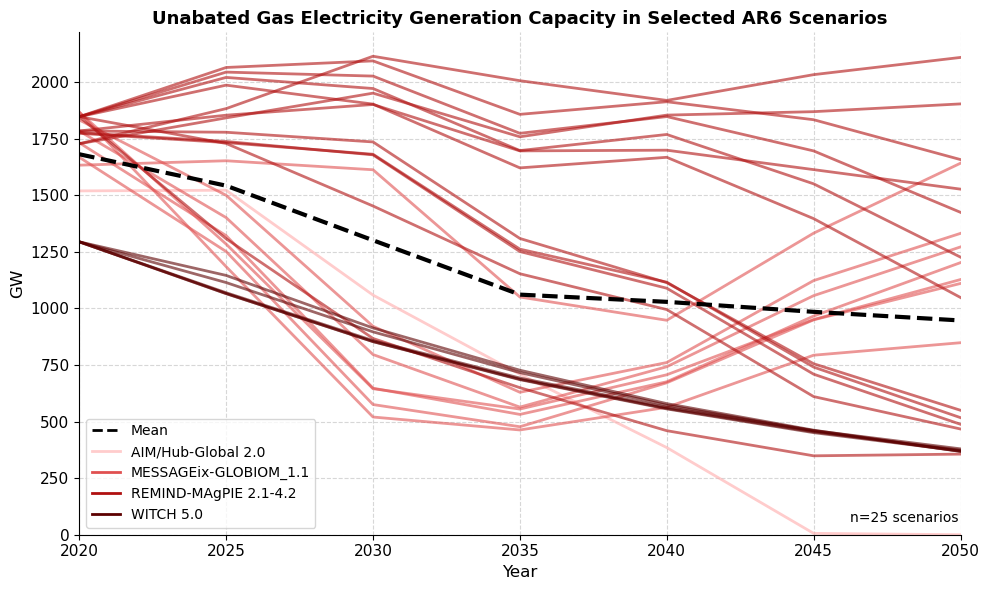

In [180]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

FIG_SIZE = (10, 6)
LINE_WIDTH = 2
SCENARIO_ALPHA = 0.6
GREY_MIX_RATIO = 0.0
MEAN_COLOR = 'black'
MEAN_ALPHA = 1.0
X_START, X_END = 2020, 2050
SHOW_SHADED_REGION = False
SHADING_COLOR = 'gray'
SHADING_ALPHA = 0.15

years_str = ['2020', '2025', '2030', '2035', '2040', '2045', '2050']
years_int = [int(y) for y in years_str]

def get_greyed_color(color, alpha=1.0, mix_ratio=0.0):
    rgb = mcolors.to_rgb(color)
    greyed_rgb = tuple((1 - mix_ratio) * c + mix_ratio * 0.75 for c in rgb)
    return greyed_rgb + (alpha,)

MODEL_COLORS = {
    'AIM/Hub-Global 2.0':        '#FFAAAA',
    'MESSAGEix-GLOBIOM_1.1':     '#E05050',
    'REMIND-MAgPIE 2.1-4.2':     '#B01010',
    'WITCH 5.0':                 '#5C0000'
}

df = pd.read_csv('gas_wo_CCS.csv')
model_counts = df['Model'].value_counts().to_dict()

plt.figure(figsize=FIG_SIZE)

if SHOW_SHADED_REGION:
    p25 = df[years_str].quantile(0.25)
    p75 = df[years_str].quantile(0.75)
    plt.fill_between(years_int, p25, p75, color=SHADING_COLOR, alpha=SHADING_ALPHA, zorder=1)

for idx, row in df.iterrows():
    model_name = row['Model']
    base_color = MODEL_COLORS.get(model_name, '#7f7f7f')
    line_color = get_greyed_color(base_color, alpha=SCENARIO_ALPHA, mix_ratio=GREY_MIX_RATIO)
    plt.plot(years_int, row[years_str], color=line_color, linewidth=LINE_WIDTH, zorder=2, label='_nolegend_')

overall_mean = df[years_str].mean()
plt.plot(years_int, overall_mean, color=MEAN_COLOR, linewidth=3, alpha=MEAN_ALPHA,
         zorder=10, label='_nolegend_', linestyle="--")

legend_elements = [Line2D([0], [0], color=MEAN_COLOR, lw=LINE_WIDTH, alpha=MEAN_ALPHA, label='Mean', linestyle="--")]
for model in MODEL_COLORS:
    if model in df['Model'].unique():
        n = model_counts.get(model, 1)
        swatch_alpha = min(SCENARIO_ALPHA * n, 1.0)
        swatch_color = get_greyed_color(MODEL_COLORS[model], alpha=swatch_alpha, mix_ratio=GREY_MIX_RATIO)
        legend_elements.append(Line2D([0], [0], color=swatch_color, lw=LINE_WIDTH, label=model))

unit = df['Unit'].iloc[0]
plt.title('Unabated Gas Electricity Generation Capacity in Selected AR6 Scenarios', fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel(unit, fontsize=12)
plt.xticks(years_int, fontsize=11)
plt.yticks(fontsize=11)
plt.xlim(X_START, X_END)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# Lines fall to lower right — legend upper right, n= lower left
plt.legend(handles=legend_elements, loc='lower left', fontsize=10)
plt.annotate(f'n={len(df)} scenarios', xy=(0.875, 0.02), xycoords='axes fraction',
             fontsize=10, color='black', ha='left', va='bottom')
plt.tight_layout()
plt.savefig('gas_unabated_capacity.png', dpi=300, bbox_inches='tight')
plt.show()

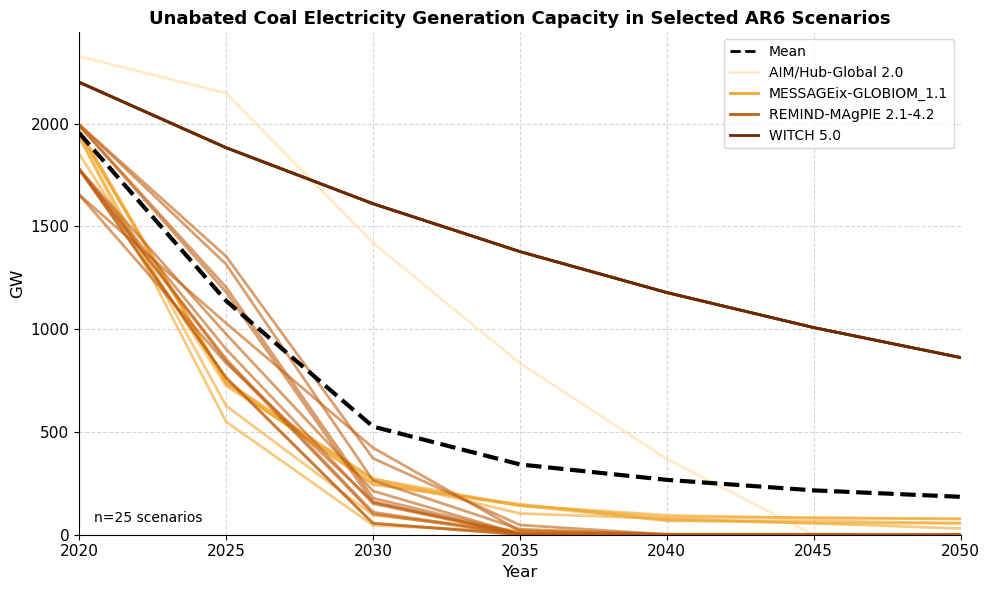

In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

FIG_SIZE = (10, 6)
LINE_WIDTH = 2
SCENARIO_ALPHA = 0.6
GREY_MIX_RATIO = 0.0
MEAN_COLOR = 'black'
MEAN_ALPHA = 1.0
X_START, X_END = 2020, 2050
SHOW_SHADED_REGION = False
SHADING_COLOR = 'gray'
SHADING_ALPHA = 0.15

years_str = ['2020', '2025', '2030', '2035', '2040', '2045', '2050']
years_int = [int(y) for y in years_str]

def get_greyed_color(color, alpha=1.0, mix_ratio=0.0):
    rgb = mcolors.to_rgb(color)
    greyed_rgb = tuple((1 - mix_ratio) * c + mix_ratio * 0.75 for c in rgb)
    return greyed_rgb + (alpha,)

MODEL_COLORS = {
    'AIM/Hub-Global 2.0':        '#FFE0A0',
    'MESSAGEix-GLOBIOM_1.1':     '#F0A830',
    'REMIND-MAgPIE 2.1-4.2':     '#C06010',
    'WITCH 5.0':                 '#6B2800'
}

df = pd.read_csv('coal_wo_CCS.csv')
model_counts = df['Model'].value_counts().to_dict()

plt.figure(figsize=FIG_SIZE)

if SHOW_SHADED_REGION:
    p25 = df[years_str].quantile(0.25)
    p75 = df[years_str].quantile(0.75)
    plt.fill_between(years_int, p25, p75, color=SHADING_COLOR, alpha=SHADING_ALPHA, zorder=1)

for idx, row in df.iterrows():
    model_name = row['Model']
    base_color = MODEL_COLORS.get(model_name, '#7f7f7f')
    line_color = get_greyed_color(base_color, alpha=SCENARIO_ALPHA, mix_ratio=GREY_MIX_RATIO)
    plt.plot(years_int, row[years_str], color=line_color, linewidth=LINE_WIDTH, zorder=2, label='_nolegend_')

overall_mean = df[years_str].mean()
plt.plot(years_int, overall_mean, color=MEAN_COLOR, linewidth=3, alpha=MEAN_ALPHA,
         zorder=10, label='_nolegend_', linestyle="--")

legend_elements = [Line2D([0], [0], color=MEAN_COLOR, lw=LINE_WIDTH, alpha=MEAN_ALPHA, label='Mean', linestyle="--")]
for model in MODEL_COLORS:
    if model in df['Model'].unique():
        n = model_counts.get(model, 1)
        swatch_alpha = min(SCENARIO_ALPHA * n, 1.0)
        swatch_color = get_greyed_color(MODEL_COLORS[model], alpha=swatch_alpha, mix_ratio=GREY_MIX_RATIO)
        legend_elements.append(Line2D([0], [0], color=swatch_color, lw=LINE_WIDTH, label=model))

if SHOW_SHADED_REGION:
    legend_elements.append(mpatches.Patch(color=SHADING_COLOR, alpha=SHADING_ALPHA, label='25th-75th Percentile'))

unit = df['Unit'].iloc[0]
plt.title('Unabated Coal Electricity Generation Capacity in Selected AR6 Scenarios', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel(unit)
plt.xlim(X_START, X_END)
plt.grid(True, linestyle='--', alpha=0.5)
# ── Publication quality finishing ──────────────────────────────────────────
plt.xticks(years_int, fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(bottom=0)
plt.xlabel(plt.gca().get_xlabel(), fontsize=12)
plt.ylabel(plt.gca().get_ylabel(), fontsize=12)
plt.title(plt.gca().get_title(), fontsize=13, fontweight='bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(handles=legend_elements, loc='upper right', fontsize=10)
plt.annotate(f'n={len(df)} scenarios', xy=(0.14, 0.02), xycoords='axes fraction',
             fontsize=10, color='black', ha='right', va='bottom')
plt.tight_layout()
plt.savefig('FILENAME.png', dpi=300, bbox_inches='tight')
plt.show()
# ──────────────────────────────────────────────────────────────────────────

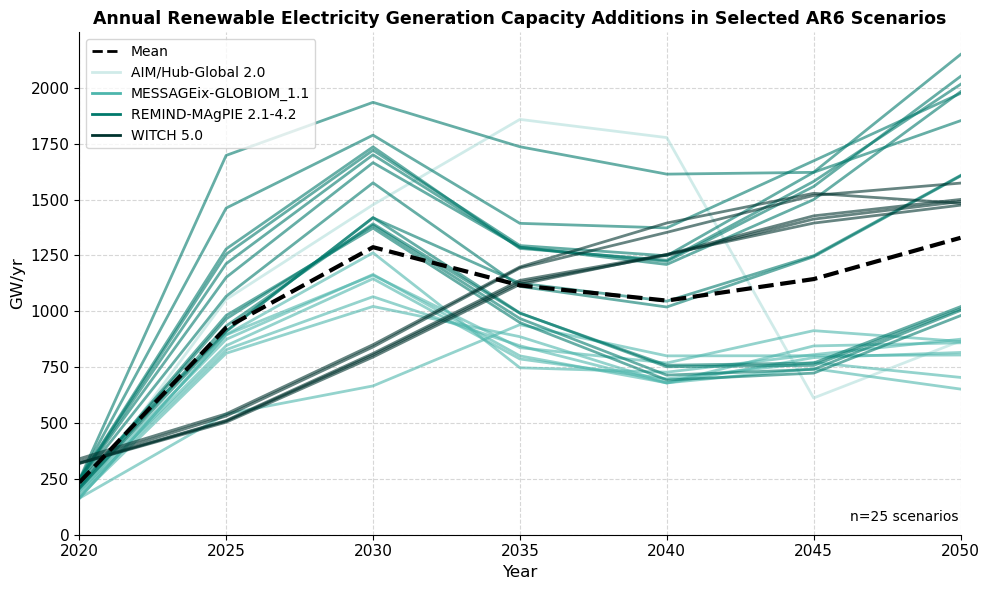

In [186]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

FIG_SIZE = (10, 6)
LINE_WIDTH = 2
SCENARIO_ALPHA = 0.6
GREY_MIX_RATIO = 0.0
MEAN_COLOR = 'black'
MEAN_ALPHA = 1.0
X_START, X_END = 2020, 2050
SHOW_SHADED_REGION = False
SHADING_COLOR = 'gray'
SHADING_ALPHA = 0.15

years_str = ['2020', '2025', '2030', '2035', '2040', '2045', '2050']
years_int = [int(y) for y in years_str]

def get_greyed_color(color, alpha=1.0, mix_ratio=0.0):
    rgb = mcolors.to_rgb(color)
    greyed_rgb = tuple((1 - mix_ratio) * c + mix_ratio * 0.75 for c in rgb)
    return greyed_rgb + (alpha,)

MODEL_COLORS = {
    'AIM/Hub-Global 2.0':        '#B2DFDB',
    'MESSAGEix-GLOBIOM_1.1':     '#4DB6AC',
    'REMIND-MAgPIE 2.1-4.2':     '#00796B',
    'WITCH 5.0':                 '#00332E'
}

df = pd.read_csv('RE_additions.csv')
model_counts = df['Model'].value_counts().to_dict()

plt.figure(figsize=FIG_SIZE)

if SHOW_SHADED_REGION:
    p25 = df[years_str].quantile(0.25)
    p75 = df[years_str].quantile(0.75)
    plt.fill_between(years_int, p25, p75, color=SHADING_COLOR, alpha=SHADING_ALPHA, zorder=1)

for idx, row in df.iterrows():
    model_name = row['Model']
    base_color = MODEL_COLORS.get(model_name, '#7f7f7f')
    line_color = get_greyed_color(base_color, alpha=SCENARIO_ALPHA, mix_ratio=GREY_MIX_RATIO)
    plt.plot(years_int, row[years_str], color=line_color, linewidth=LINE_WIDTH, zorder=2, label='_nolegend_')

overall_mean = df[years_str].mean()
plt.plot(years_int, overall_mean, color=MEAN_COLOR, linewidth=3, alpha=MEAN_ALPHA,
         zorder=10, label='_nolegend_', linestyle="--")

legend_elements = [Line2D([0], [0], color=MEAN_COLOR, lw=LINE_WIDTH, alpha=MEAN_ALPHA, label='Mean', linestyle="--")]
for model in MODEL_COLORS:
    if model in df['Model'].unique():
        n = model_counts.get(model, 1)
        swatch_alpha = min(SCENARIO_ALPHA * n, 1.0)
        swatch_color = get_greyed_color(MODEL_COLORS[model], alpha=swatch_alpha, mix_ratio=GREY_MIX_RATIO)
        legend_elements.append(Line2D([0], [0], color=swatch_color, lw=LINE_WIDTH, label=model))

unit = df['Unit'].iloc[0]
plt.title('Annual Renewable Electricity Generation Capacity Additions in Selected AR6 Scenarios', fontsize=12.5, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel(unit, fontsize=12)
plt.xticks(years_int, fontsize=11)
plt.yticks(fontsize=11)
plt.xlim(X_START, X_END)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# Lines rise from lower left — legend lower right, n= upper left
plt.legend(handles=legend_elements, loc='upper left', fontsize=10)
plt.annotate(f'n={len(df)} scenarios', xy=(0.875, 0.05), xycoords='axes fraction',
             fontsize=10, color='black', ha='left', va='top')
plt.tight_layout()
plt.savefig('renewable_additions.png', dpi=300, bbox_inches='tight')
plt.show()

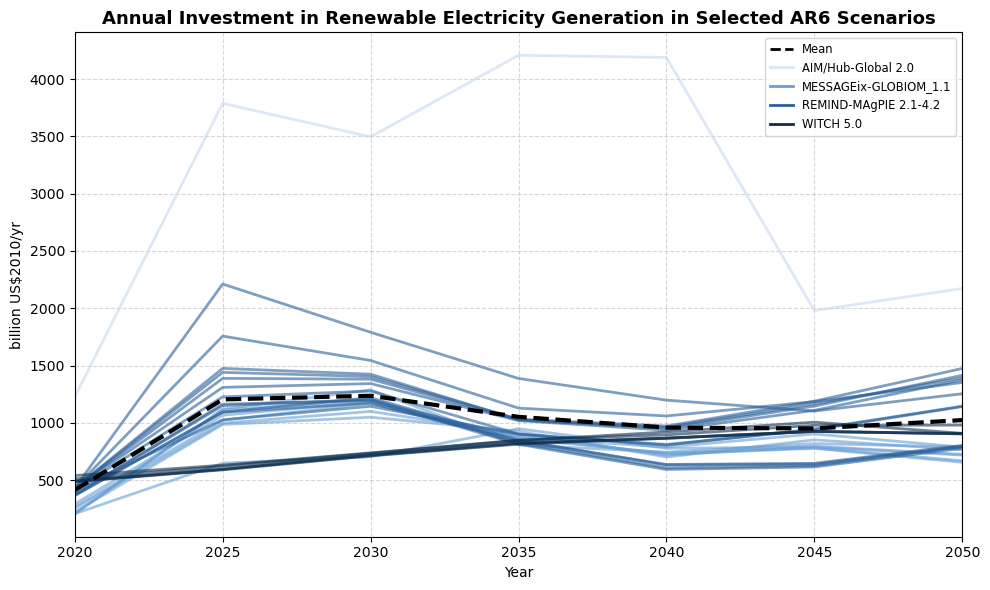

In [188]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

FIG_SIZE = (10, 6)
LINE_WIDTH = 2
SCENARIO_ALPHA = 0.6
GREY_MIX_RATIO = 0.0
MEAN_COLOR = 'black'
MEAN_ALPHA = 1.0
X_START, X_END = 2020, 2050
SHOW_SHADED_REGION = False
SHADING_COLOR = 'gray'
SHADING_ALPHA = 0.15

years_str = ['2020', '2025', '2030', '2035', '2040', '2045', '2050']
years_int = [int(y) for y in years_str]

def get_greyed_color(color, alpha=1.0, mix_ratio=0.0):
    rgb = mcolors.to_rgb(color)
    greyed_rgb = tuple((1 - mix_ratio) * c + mix_ratio * 0.75 for c in rgb)
    return greyed_rgb + (alpha,)

MODEL_COLORS = {
    'AIM/Hub-Global 2.0':        '#C6D9F0',
    'MESSAGEix-GLOBIOM_1.1':     '#6A9FD4',
    'REMIND-MAgPIE 2.1-4.2':     '#2A6099',
    'WITCH 5.0':                 '#0D2E4E'
}

df = pd.read_csv('RE_investments.csv')
model_counts = df['Model'].value_counts().to_dict()

plt.figure(figsize=FIG_SIZE)

if SHOW_SHADED_REGION:
    p25 = df[years_str].quantile(0.25)
    p75 = df[years_str].quantile(0.75)
    plt.fill_between(years_int, p25, p75, color=SHADING_COLOR, alpha=SHADING_ALPHA, zorder=1)

for idx, row in df.iterrows():
    model_name = row['Model']
    base_color = MODEL_COLORS.get(model_name, '#7f7f7f')
    line_color = get_greyed_color(base_color, alpha=SCENARIO_ALPHA, mix_ratio=GREY_MIX_RATIO)
    plt.plot(years_int, row[years_str], color=line_color, linewidth=LINE_WIDTH, zorder=2, label='_nolegend_')

overall_mean = df[years_str].mean()
plt.plot(years_int, overall_mean, color=MEAN_COLOR, linewidth=3, alpha=MEAN_ALPHA,
         zorder=10, label='_nolegend_', linestyle="--")

legend_elements = [Line2D([0], [0], color=MEAN_COLOR, lw=LINE_WIDTH, alpha=MEAN_ALPHA, label='Mean', linestyle="--")]
for model in MODEL_COLORS:
    if model in df['Model'].unique():
        n = model_counts.get(model, 1)
        swatch_alpha = min(SCENARIO_ALPHA * n, 1.0)
        swatch_color = get_greyed_color(MODEL_COLORS[model], alpha=swatch_alpha, mix_ratio=GREY_MIX_RATIO)
        legend_elements.append(Line2D([0], [0], color=swatch_color, lw=LINE_WIDTH, label=model))

if SHOW_SHADED_REGION:
    legend_elements.append(mpatches.Patch(color=SHADING_COLOR, alpha=SHADING_ALPHA, label='25th-75th Percentile'))

unit = df['Unit'].iloc[0]
plt.title('Annual Investment in Renewable Electricity Generation in Selected AR6 Scenarios', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel(unit)
plt.xlim(X_START, X_END)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(handles=legend_elements, loc='best', fontsize='small')
plt.tight_layout()
plt.show()